## 🧬 HGSRouter

**Concepts:** [HGS-CVRP](../routers.md#hgs-cvrp) · [Meta-heuristics](../routers.md#meta-heuristics) **Advanced API:** [🧬 HGS-CVRP](lo21_hgs.ipynb)

This notebook uses `OptiWindNet` to route the collector system cables via [HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter).

### HGS (Hybrid Genetic Search)

[HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) applies _Hybrid Genetic Search_ to the electrical network of a given turbine layout, treating it as a _Capacitated Vehicle Routing Problem_ — see [HGS-CVRP](../routers.md#hgs-cvrp) for what the router does and how its feeder options behave.

It is slower than [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) but typically yields _better-quality networks_, especially for medium and large wind farms with one substation.

#### Constructor: `HGSRouter(...)`

[HGSRouter()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) requires a [time_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.time_limit); the remaining arguments control the feeder count, load balancing, the ringed topology and reproducibility. They are documented in the API Reference under [optiwindnet.api.HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter); how they behave is described in [HGS-CVRP](../routers.md#hgs-cvrp).

**Example**

```python
wf = WindFarmNetwork(...)
wf.optimize(
 router=HGSRouter(
 time_limit=60,
 feeder_limit=10,
 feeder_exact=True,
 balanced=True,
 )
)
```

- HGSRouter trades speed for _higher-quality networks_ and is particularly useful when:
- A better solution is worth longer runtime (compared to [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter))
- The number of turbines connected to each feeder needs to be balanced

- On its own, [feeder_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.feeder_limit) is an _upper bound_: HGS is free to use fewer feeders and normally settles at the minimum feasible number. Pass `feeder_exact=True` to pin the feeder count to [feeder_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.feeder_limit) instead. This requires `balanced=True` and a single substation, and the count must be between the minimum feasible number and one feeder per turbine.

- In _multi-substation networks_, the router can only enforce a [feeder_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.feeder_limit) that is the minimum feasible number. The parameter may also be omitted (meaning unlimited feeders).

> [HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) produces _radial_ topologies (or _ringed_, on request). Since a _radial_ topology is a special case of the _branched_ topology, its solutions can warm-start both _branched_- and _radial_-topology models — see [Warm-starting](../routers.md#warm-starting).

### Load data

import required modules

In [1]:
from optiwindnet.api import WindFarmNetwork, HGSRouter

Create an instance of `wfn` using [.from_pbf()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.from_pbf)

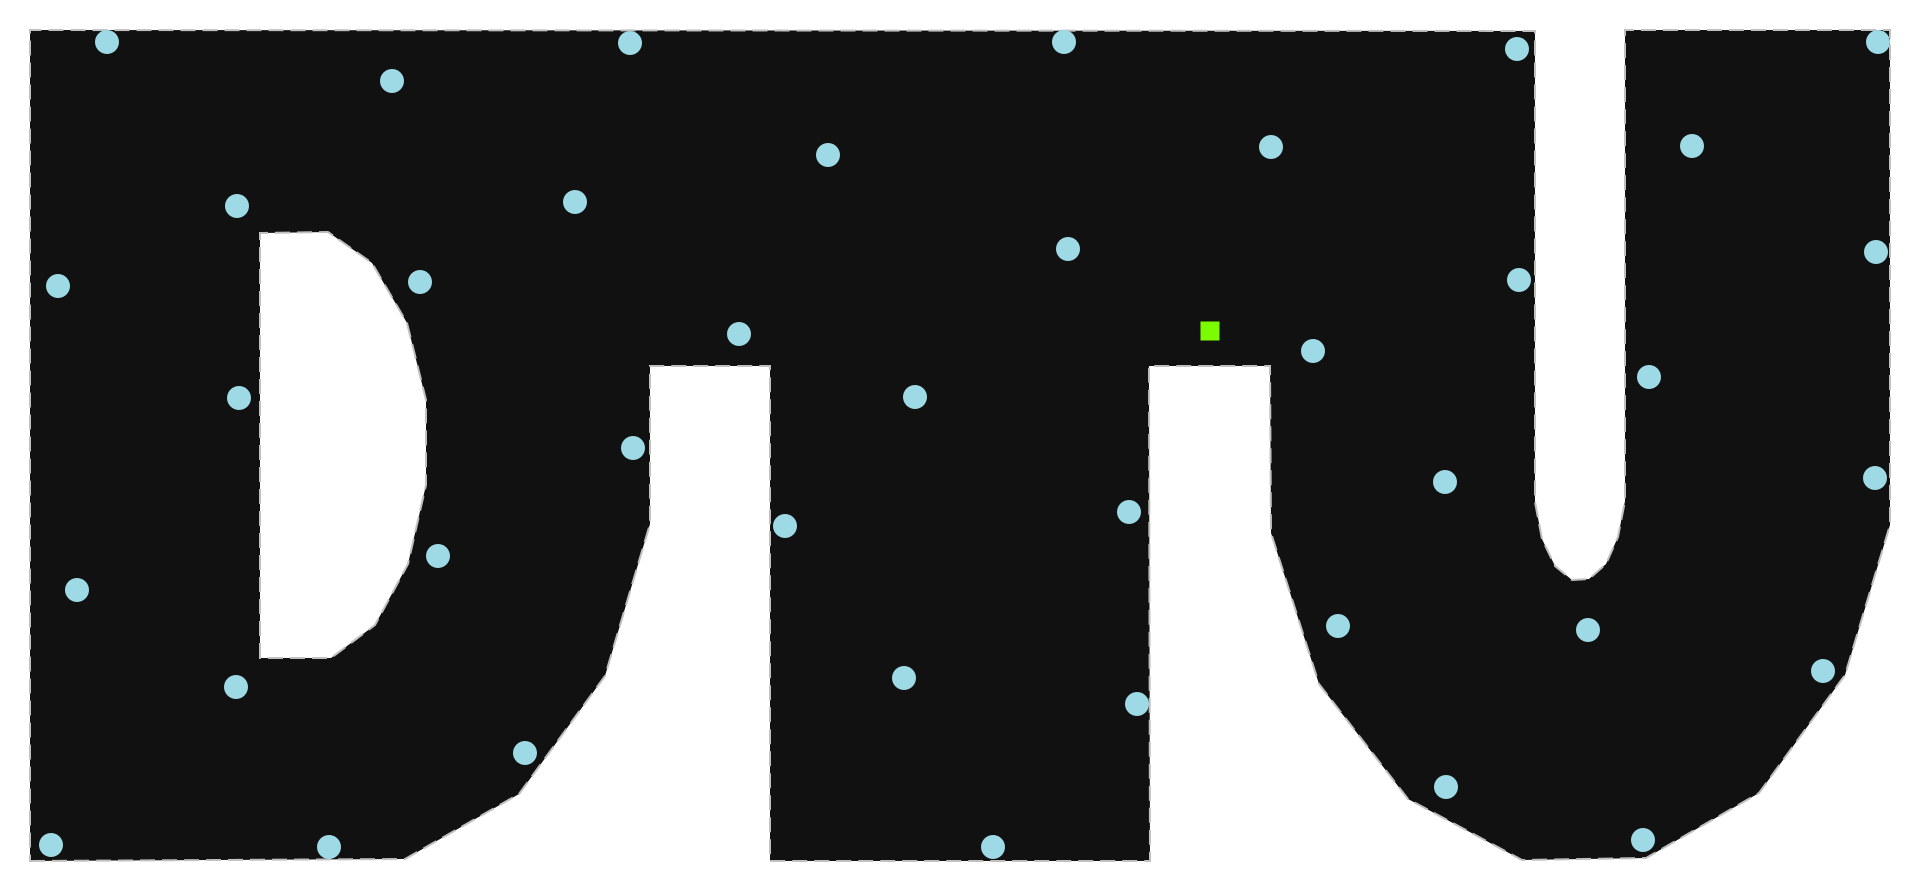

In [2]:
wfn = WindFarmNetwork.from_pbf(filepath='data/DTU_letters.osm.pbf', cables= [(7, 2000.0)])
wfn

### Optimize with HGSRouter

In [3]:
res = wfn.optimize(router=HGSRouter(time_limit=3))
wfn.length()

1596.1580407347585

#### Get solution_time

We can see the solution time for HGS using:

In [4]:
wfn.S.graph['solution_time']

0.02

It prints the computation time for each HGS algorithm call (which run in parallel in multi-core systems); each call handling one substation and its turbine cluster. The router partitions the turbines automatically in clusters, with the constraint of keeping the total number of feeders at the minimum.

#### Choosing `time_limit` wisely

Based on the solution times observed in the previous step, we can make an informed decision about the time limit for the HGS router. If increasing the time limit does not significantly improve the solution (e.g., does not result in a noticeably shorter cable length), we can consider reducing it to save computational resources. In this case, a time limit of 0.1 second appears to be sufficient, as it is well above all the solution times.

In [5]:
wfn.optimize(router=HGSRouter(time_limit=0.1))
wfn.S.graph['solution_time']

0.03

##### Check the length

We can see that, as expected, reducing the time limit from 10 seconds to 1 seconds has not affected the resultant length.

In [6]:
wfn.length()

1596.1580407347585

#### Plot the Optimized Network Graph

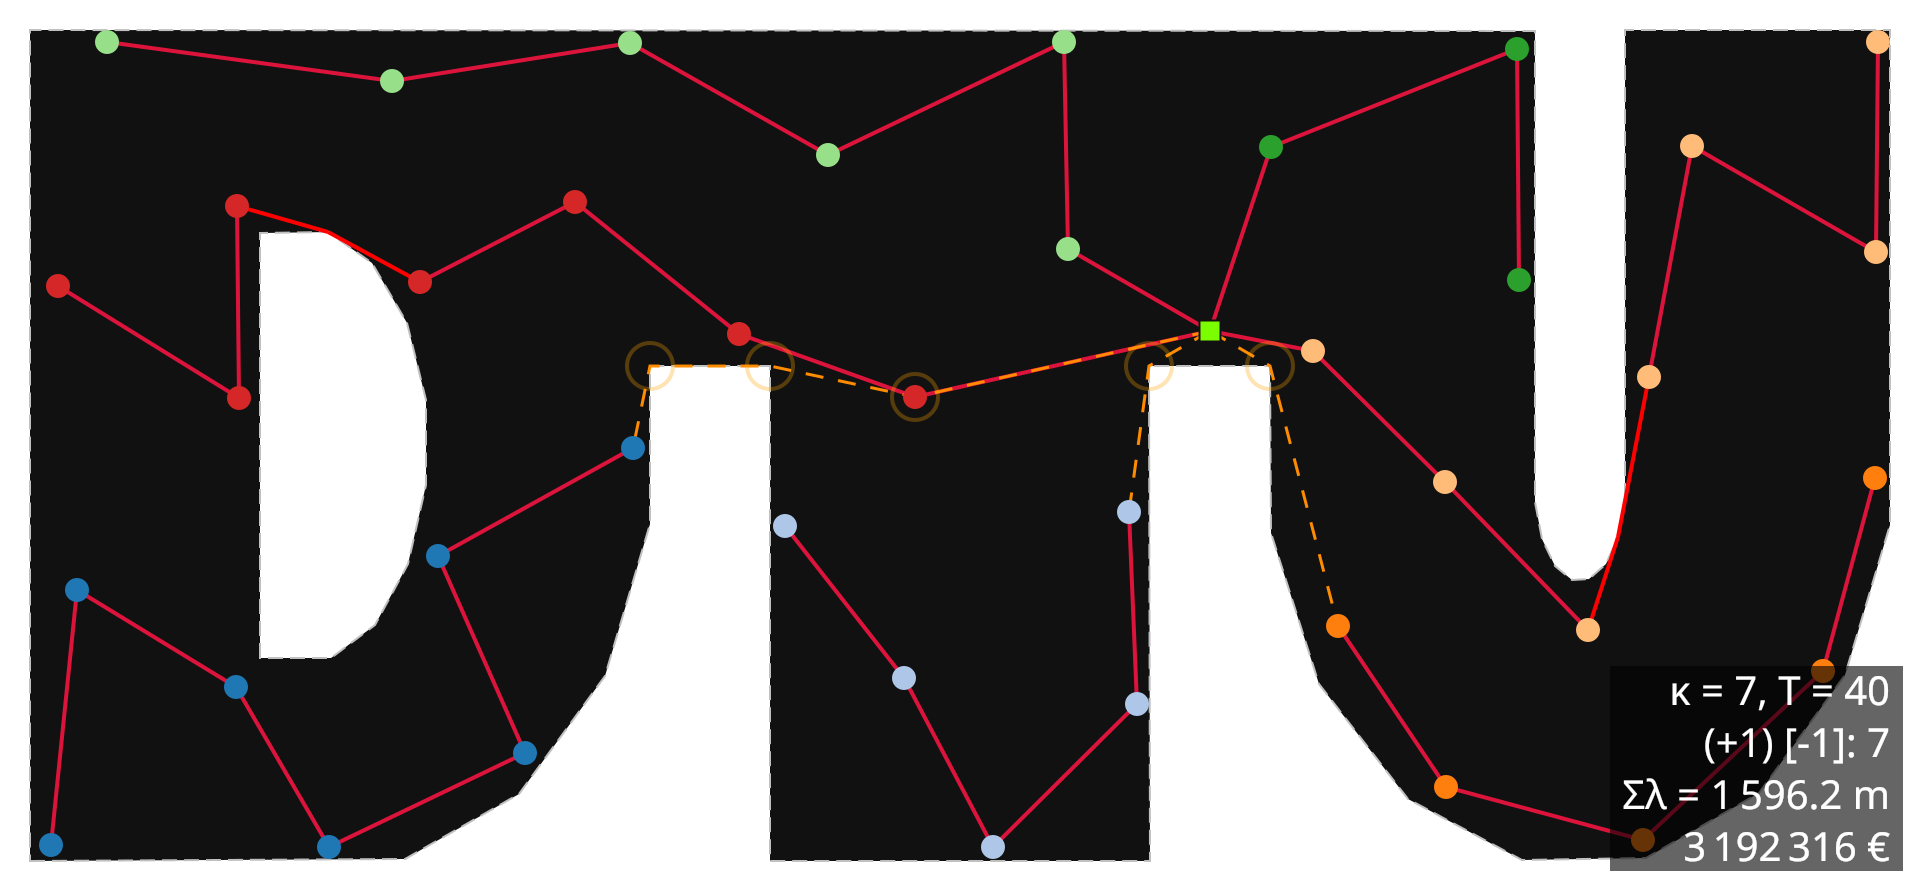

In [7]:
wfn